In [1]:
%pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

Random Forest Accuracy: 0.8092
AUC Score: 0.8712
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       114
           1       0.64      0.55      0.59        38

    accuracy                           0.81       152
   macro avg       0.75      0.72      0.73       152
weighted avg       0.80      0.81      0.80       152



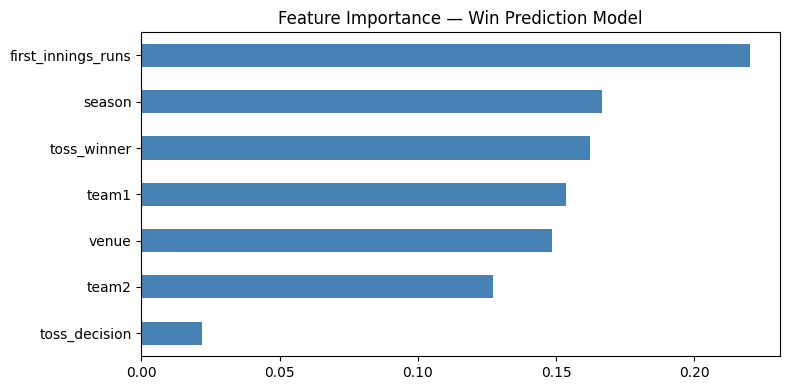

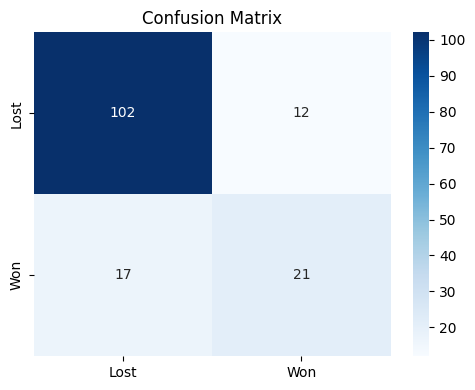

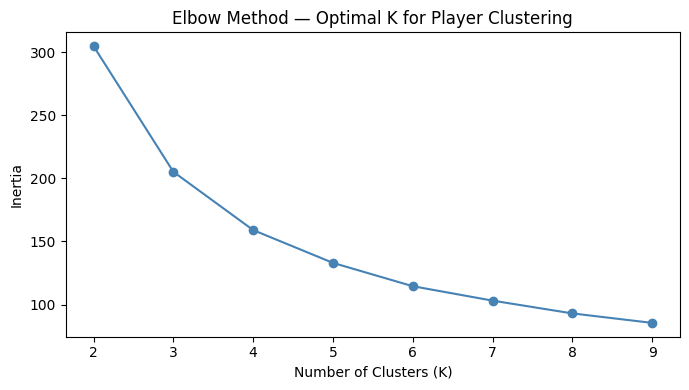

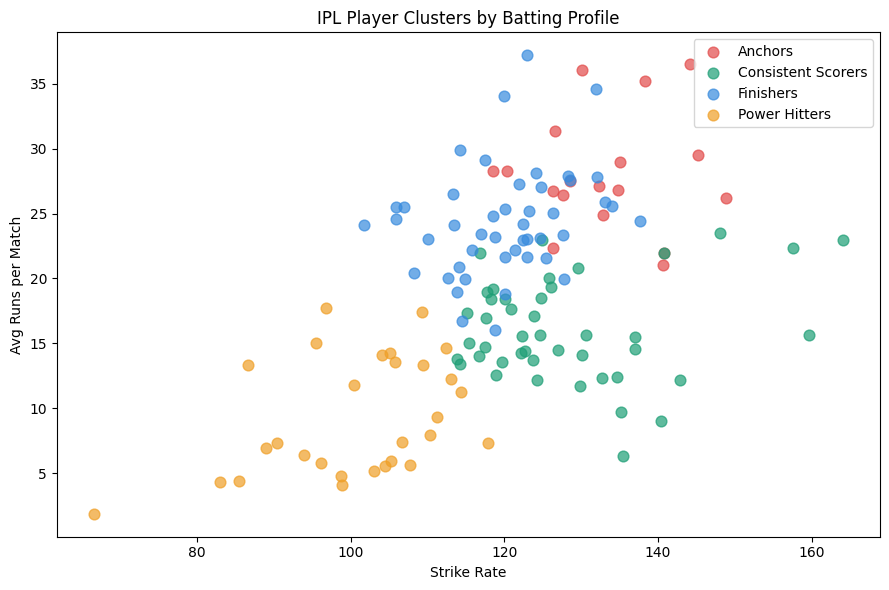


Top players per cluster:
                           batsman  total_runs  strike_rate
player_type                                                
Anchors            374    SK Raina        4548       135.00
                   431     V Kohli        4423       126.59
                   323   RG Sharma        4207       128.50
Consistent Scorers 109    DJ Bravo        1262       122.29
                   143  GJ Maxwell        1229       157.56
                   157   IK Pathan        1150       116.75
Finishers          38    AM Rahane        3057       117.49
                   195  KD Karthik        2903       123.01
                   232     M Vijay        2511       120.03
Power Hitters      296   PP Chawla         515       110.28
                   227    M Manhas         514       105.76
                   163     J Botha         409       112.36


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../outputs/metrics', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

# ════════════════════════════════════════════
# MODEL 1: Match Win Prediction (Classification)
# ════════════════════════════════════════════
matches = pd.read_csv('../data/processed/matches_cleaned.csv')
deliveries = pd.read_csv('../data/processed/deliveries_cleaned.csv')

# Build feature table
batting_totals = deliveries.groupby(
    ['match_id', 'batting_team']
)['total_runs'].sum().reset_index()

first_innings = batting_totals.groupby('match_id').first().reset_index()
first_innings.columns = ['id', 'batting_team', 'first_innings_runs']

df = matches.merge(first_innings, on='id', how='left')

# Encode categorical variables
le = LabelEncoder()
for col in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']:
    df[col] = le.fit_transform(df[col].astype(str))

df['target'] = (df['winner'] == df['batting_team']).astype(int)
df['first_innings_runs'] = df['first_innings_runs'].fillna(df['first_innings_runs'].median())

features = ['team1', 'team2', 'toss_winner', 'toss_decision',
            'venue', 'season', 'first_innings_runs']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
report = classification_report(y_test, y_pred, output_dict=True)

print(f"Random Forest Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(classification_report(y_test, y_pred))

# Save metrics
metrics_df = pd.DataFrame(report).transpose()
metrics_df.to_csv('../outputs/metrics/classification_report.csv')

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Win Prediction Model')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_importance.png', dpi=150)
plt.show()

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Lost', 'Won'], yticklabels=['Lost', 'Won'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrix.png', dpi=150)
plt.show()

# ════════════════════════════════════════════
# MODEL 2: Player Performance Clustering (K-Means)
# ════════════════════════════════════════════
batsman_stats = deliveries.groupby('batsman').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count'),
    fours=('batsman_runs', lambda x: (x == 4).sum()),
    sixes=('batsman_runs', lambda x: (x == 6).sum()),
    matches_played=('match_id', 'nunique')
).reset_index()

batsman_stats['strike_rate'] = (
    batsman_stats['total_runs'] / batsman_stats['balls_faced'] * 100
).round(2)
batsman_stats['avg_runs_per_match'] = (
    batsman_stats['total_runs'] / batsman_stats['matches_played']
).round(2)

# Filter players with at least 20 matches
batsman_stats = batsman_stats[batsman_stats['matches_played'] >= 20]

cluster_features = ['total_runs', 'strike_rate', 'avg_runs_per_match', 'sixes']
X_cluster = batsman_stats[cluster_features].fillna(0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 10), inertias, marker='o', color='steelblue')
ax.set_title('Elbow Method — Optimal K for Player Clustering')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('../outputs/plots/elbow_method.png', dpi=150)
plt.show()

# Final K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
batsman_stats['cluster'] = kmeans.fit_predict(X_scaled)

cluster_labels = {0: 'Power Hitters', 1: 'Anchors', 2: 'Consistent Scorers', 3: 'Finishers'}
batsman_stats['player_type'] = batsman_stats['cluster'].map(cluster_labels)

# Scatter plot
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#EF9F27']
for i, (label, group) in enumerate(batsman_stats.groupby('player_type')):
    ax.scatter(group['strike_rate'], group['avg_runs_per_match'],
               label=label, alpha=0.7, s=60, color=colors[i])
ax.set_xlabel('Strike Rate')
ax.set_ylabel('Avg Runs per Match')
ax.set_title('IPL Player Clusters by Batting Profile')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/player_clusters.png', dpi=150)
plt.show()

# Save cluster results
batsman_stats.to_csv('../outputs/metrics/player_clusters.csv', index=False)
print("\nTop players per cluster:")
print(batsman_stats.groupby('player_type')[['batsman', 'total_runs', 'strike_rate']].apply(
    lambda g: g.nlargest(3, 'total_runs')
))